In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


In [2]:
data = {
    "Soil_Moisture": ["Dry", "Dry", "Moist", "Wet", "Moist", "Dry", "Wet"],
    "Temperature": ["High", "Moderate", "High", "Low", "Moderate", "High", "Low"],
    "Humidity": ["Low", "High", "High", "High", "Low", "Low", "High"],
    "Time_of_Day": ["Morning", "Evening", "Morning", "Evening", "Morning", "Evening", "Morning"],
    "Irrigation": ["ON", "ON", "OFF", "OFF", "OFF", "ON", "OFF"]
}

df = pd.DataFrame(data)
df


,Soil_Moisture,Temperature,Humidity,Time_of_Day,Irrigation
0,Dry,High,Low,Morning,ON
1,Dry,Moderate,High,Evening,ON
2,Moist,High,High,Morning,OFF
3,Wet,Low,High,Evening,OFF
4,Moist,Moderate,Low,Morning,OFF
5,Dry,High,Low,Evening,ON
6,Wet,Low,High,Morning,OFF


In [3]:
encoders = {}

for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    encoders[column] = le

df


,Soil_Moisture,Temperature,Humidity,Time_of_Day,Irrigation
0,0,0,1,1,1
1,0,2,0,0,1
2,1,0,0,1,0
3,2,1,0,0,0
4,1,2,1,1,0
5,0,0,1,0,1
6,2,1,0,1,0


In [4]:
X = df.drop("Irrigation", axis=1)
y = df["Irrigation"]


In [5]:
model = RandomForestClassifier(
    n_estimators=5,        # number of trees
    criterion="entropy",
    random_state=42
)

model.fit(X, y)


,n_estimators,5
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
new_sample = pd.DataFrame({
    "Soil_Moisture": encoders["Soil_Moisture"].transform(["Dry"]),
    "Temperature": encoders["Temperature"].transform(["High"]),
    "Humidity": encoders["Humidity"].transform(["Low"]),
    "Time_of_Day": encoders["Time_of_Day"].transform(["Morning"])
})

prediction = model.predict(new_sample)

decision = encoders["Irrigation"].inverse_transform(prediction)[0]
decision


'ON'

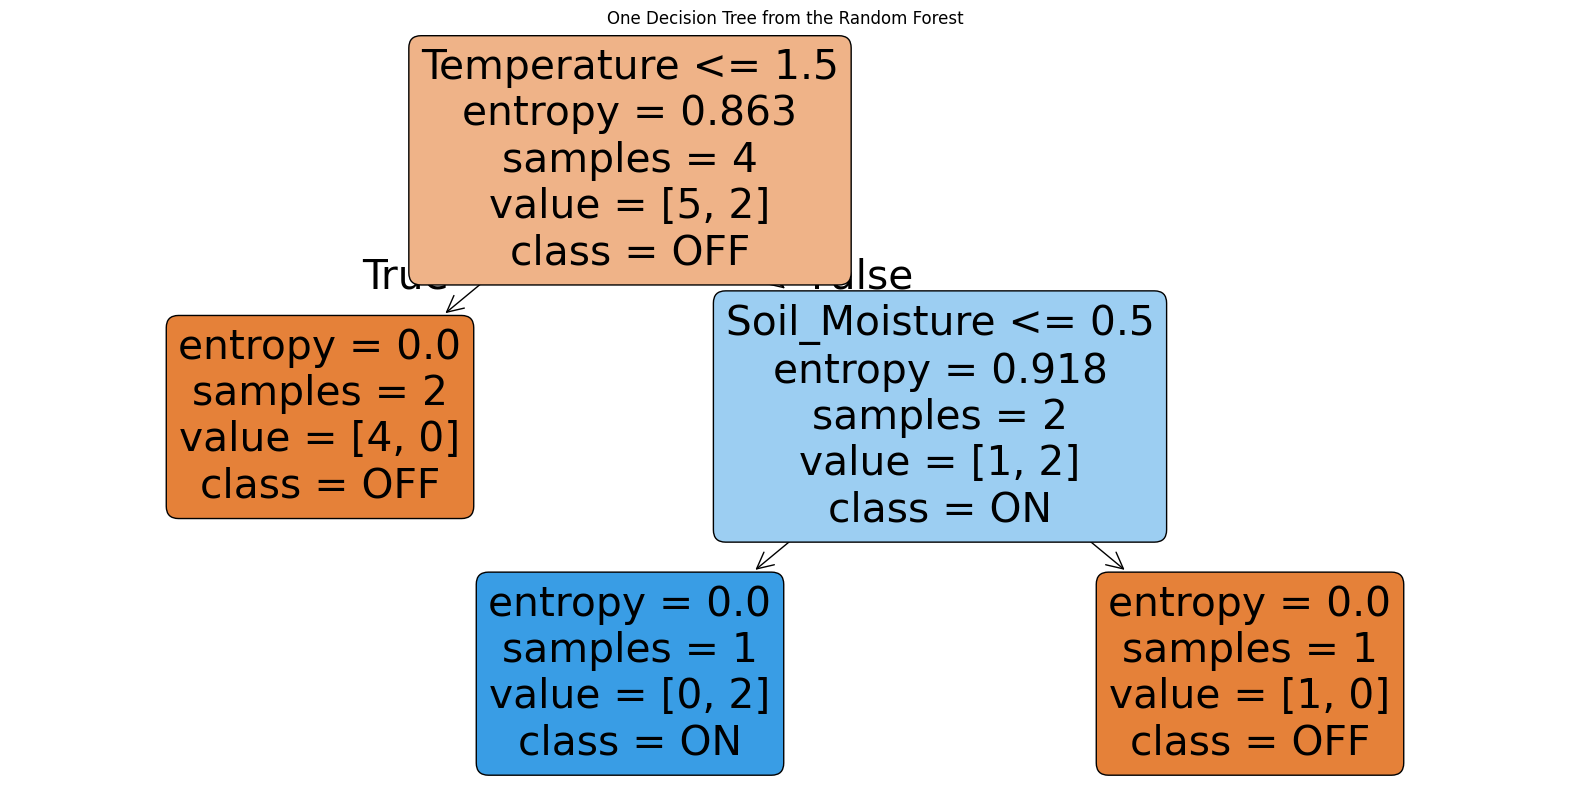

In [7]:
plt.figure(figsize=(20, 10))

plot_tree(
    model.estimators_[0],
    feature_names=list(X.columns),
    class_names=list(encoders["Irrigation"].classes_),
    filled=True,
    rounded=True
)

plt.title("One Decision Tree from the Random Forest")
plt.show()
